# Track Day Telemetry Analysis
**Josh Miyamoto | Portfolio Project #2**

Analyzes Laguna Seca lap data to find optimal pit stop window.
Upload telemetry.csv → run all cells → get chart + insights.

In [9]:
from google.colab import files
uploaded = files.upload()
# select your telemetry.csv when the picker opens

Saving Telemetry log - telemetry.csv to Telemetry log - telemetry (1).csv


In [10]:
!pip install seaborn -q

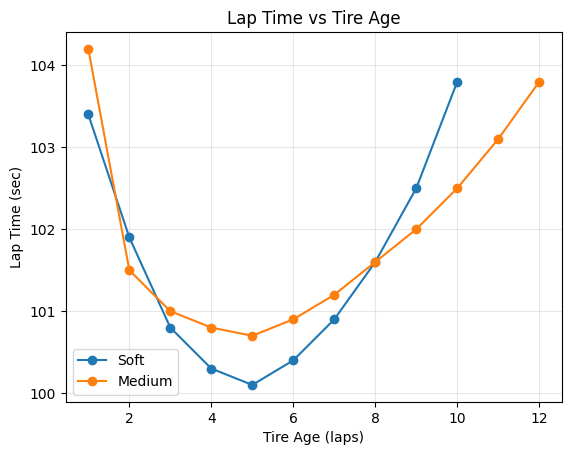

Best lap: 1:40.100
Soft avg deg: 1.47%/lap
Medium avg deg: 1.23%/lap


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

df = pd.read_csv("Telemetry log - telemetry.csv", skipinitialspace=True)
df["lap_time_sec"] = pd.to_numeric(df["lap_time_sec"], errors="coerce")
df["tire_laps_used"] = pd.to_numeric(df["tire_laps_used"], errors="coerce")
df["sector1_sec"] = pd.to_numeric(df["sector1_sec"], errors="coerce")
df["sector2_sec"] = pd.to_numeric(df["sector2_sec"], errors="coerce")
df["sector3_sec"] = pd.to_numeric(df["sector3_sec"], errors="coerce")

best_lap = df["lap_time_sec"].min()
df["gap_to_best"] = df["lap_time_sec"] - best_lap
compound_bests = df.groupby("tire_compound")["lap_time_sec"].min()
df["tire_deg_pct"] = df.apply(lambda r: (r["lap_time_sec"] - compound_bests[r["tire_compound"]]) / compound_bests[r["tire_compound"]] * 100, axis=1)

# Chart
for compound in df["tire_compound"].unique():
    sub = df[df["tire_compound"] == compound]
    plt.plot(sub["tire_laps_used"], sub["lap_time_sec"], "o-", label=compound)

plt.title("Lap Time vs Tire Age")
plt.xlabel("Tire Age (laps)")
plt.ylabel("Lap Time (sec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("tire_degradation.png")
plt.show()

print(f"Best lap: {int(best_lap//60)}:{best_lap%60:06.3f}")
print(f"Soft avg deg: {df[df['tire_compound']=='Soft']['tire_deg_pct'].mean():.2f}%/lap")
print(f"Medium avg deg: {df[df['tire_compound']=='Medium']['tire_deg_pct'].mean():.2f}%/lap")

In [12]:
from google.colab import files
files.download("tire_degradation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>